In [14]:
%pip install pymysql
%pip install mysql-connector-python pandas
%pip install SQLAlchemy
%pip install load_dotenv
%pip install pandas
%pip install matplotlib
%pip install ipython-sql
%pip install scipy

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


# Set up database

In [15]:
from dotenv import load_dotenv
import os

load_dotenv()

user = os.getenv("DB_USER")
password = os.getenv("DB_PASS")
host = os.getenv("DB_HOST")
dbname = os.getenv("DB_NAME")

from sqlalchemy import create_engine
engine = create_engine(f"mysql+mysqlconnector://{user}:{password}@{host}/{dbname}", connect_args={'init_command': 'SET time_zone="+07:00"'})

# PHONE SCREEN

In [16]:
import pandas as pd
import matplotlib.pyplot as plt

In [17]:
query = "SELECT `DAY`, `SCREEN_TIME`, `SOCIAL`, `SCREEN_TIME` - `SOCIAL` AS `OTHERS` FROM `SAMSUNG_PHONE_SCREEN` NATURAL JOIN `DAY`"
ps = pd.read_sql(query, engine)

In [18]:
ps.head()

,DAY,SCREEN_TIME,SOCIAL,OTHERS
0,2025-06-20,399.0,353.0,46.0
1,2025-06-21,226.0,117.0,109.0
2,2025-06-22,274.0,195.0,79.0
3,2025-06-23,300.0,206.0,94.0
4,2025-06-24,123.0,113.0,10.0


In [19]:
print(ps[['SCREEN_TIME','SOCIAL', 'OTHERS']].describe())

       SCREEN_TIME     SOCIAL      OTHERS
count    20.000000   20.00000   20.000000
mean    314.700000  180.70000  134.000000
std     108.613317  103.43424   71.454071
min     123.000000   47.00000   10.000000
25%     235.250000  110.75000   90.250000
50%     301.500000  150.50000  117.500000
75%     394.500000  226.50000  171.250000
max     549.000000  452.00000  278.000000


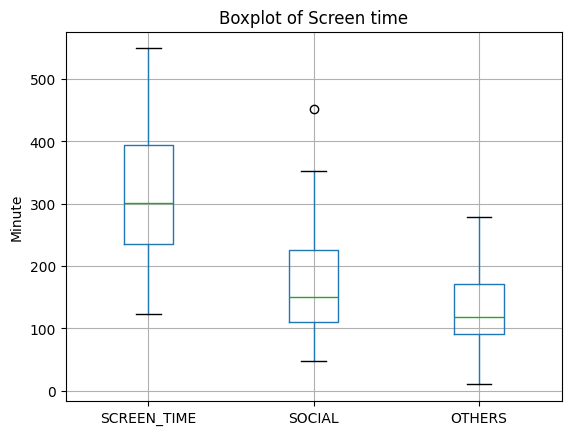

In [20]:
ps.boxplot(column=['SCREEN_TIME','SOCIAL', 'OTHERS'])

plt.title('Boxplot of Screen time')
plt.ylabel('Minute')
plt.show()

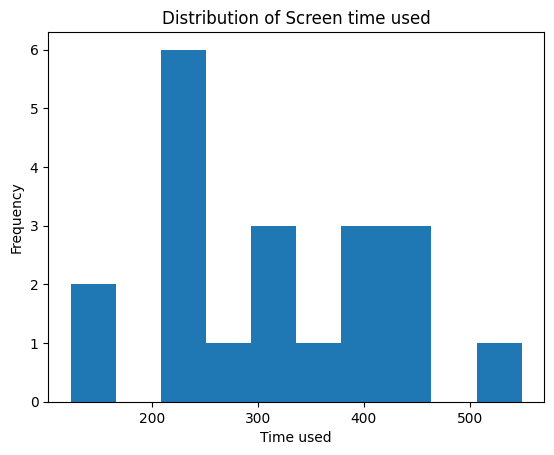

In [21]:
ps['SCREEN_TIME'].plot.hist()
plt.xlabel("Time used")
plt.title("Distribution of Screen time used")
plt.show()

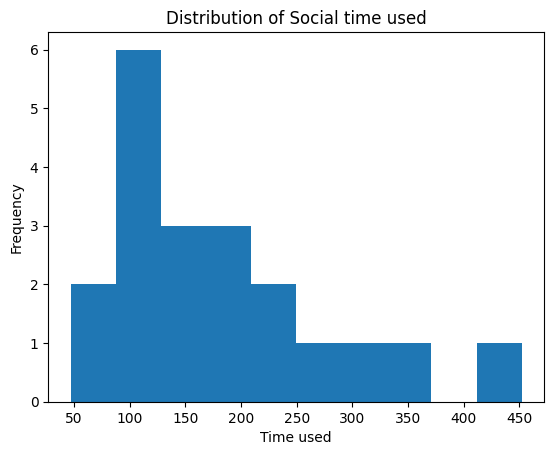

In [22]:
ps['SOCIAL'].plot.hist()
plt.xlabel("Time used")
plt.title("Distribution of Social time used")
plt.show()

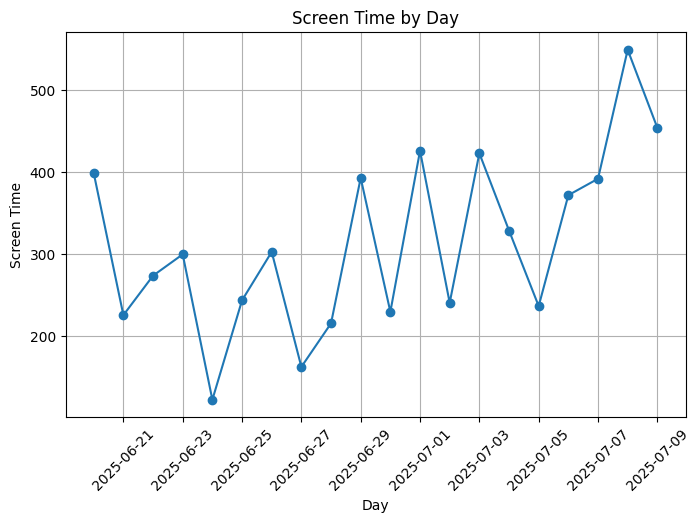

In [23]:
plt.figure(figsize=(8, 5))
plt.plot(ps['DAY'], ps['SCREEN_TIME'], marker='o')
plt.xlabel('Day')
plt.ylabel('Screen Time')
plt.title('Screen Time by Day')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

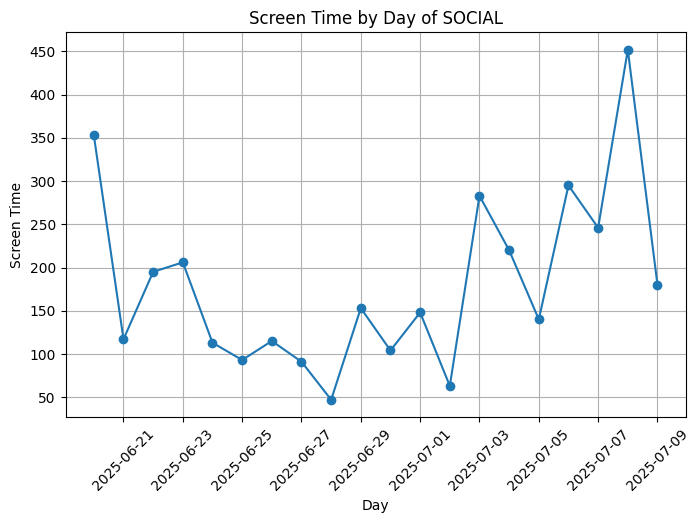

In [24]:
plt.figure(figsize=(8, 5))
plt.plot(ps['DAY'], ps['SOCIAL'], marker='o')
plt.xlabel('Day')
plt.ylabel('Screen Time')
plt.title('Screen Time by Day of SOCIAL')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

$z$-score

In [25]:
from scipy.stats import zscore

ps['z_score of SCREEN_TIME'] = zscore(ps['SCREEN_TIME'])
ps['z_score of SOCIAL'] = zscore(ps['SOCIAL'])

ps.head()

,DAY,SCREEN_TIME,SOCIAL,OTHERS,z_score of SCREEN_TIME,z_score of SOCIAL
0,2025-06-20,399.0,353.0,46.0,0.796311,1.709067
1,2025-06-21,226.0,117.0,109.0,-0.837874,-0.631849
2,2025-06-22,274.0,195.0,79.0,-0.384459,0.141844
3,2025-06-23,300.0,206.0,94.0,-0.138858,0.250954
4,2025-06-24,123.0,113.0,10.0,-1.810828,-0.671526


Chebyshev's theorem

In [26]:
z = 1.6634959668526281
print(1-(1/(z*z)))

0.6386263390044107
